# Classical Alexander duality to find representative cycles
Without relative subdivision/tight supplement

In [90]:
import numpy as np
import matplotlib.pyplot as plt
import itertools
from itertools import combinations
import networkx as nx

from gudhi import AlphaComplex as AC

In [91]:
from src.abstract_subdivision import AbstractSubdivision

Subs = {i: AbstractSubdivision(i) for i in range(2,5)}

from src.relative_subdivision import subdivision
from src.alpha_builder import AlphaComplex, getAlphaComplex
from src.visualization import draw_2d_simplicial_complex, draw_Sup

#### Subdivision

In [92]:
def subdivide_complex(M, pointsM, L, pointsL, Subs):
    sM, sPointsM = subdivision(M, pointsM, Subs)
    sL, sPointsL = subdivision(L, pointsL, Subs)
    return sM, sPointsM, sL, sPointsL

#### Computing the outer boundary 
i.e. the point at infinity

In [93]:
def compute_outer_boundary(sM):
    
    edges = sorted([s for s in sM if len(s) == 2])
    triangles = sorted([s for s in sM if len(s) == 3])
    
    edge_index = {tuple(e): i for i, e in enumerate(edges)}
    
    boundary_count = np.zeros(len(edges), dtype=int)
    
    for T in triangles:
        for e in [(T[0],T[1]), (T[1],T[2]), (T[0],T[2])]:
            boundary_count[edge_index[tuple(sorted(e))]] += 1
    
    boundary_mod2 = boundary_count % 2
    
    marked_edges = [
        edges[i]
        for i in range(len(edges))
        if boundary_mod2[i] == 1
    ]
    
    return marked_edges

#### The classical supplement

In [94]:
def compute_supplement(sM, sPointsM, sL, sPointsL):
    """
    Assuming L < M is a subcomplex of M, and sL and sM are their subdivisions,
    compute the supplement of L in M using full subdivision.
    """

    # Build dictionary of L vertices (rounded for stability)
    L_vertex_dict = {
        tuple(np.round(sPointsL[j, :], 12)): j
        for j in range(sPointsL.shape[0])
    }

    # Detect which vertices in sM belong to sL
    SubComplexIndices = []
    
    for i in range(sPointsM.shape[0]):
        key = tuple(np.round(sPointsM[i, :], 12))
        if key in L_vertex_dict:
            SubComplexIndices.append(i)
    
    SubComplexIndices = sorted(SubComplexIndices)
    
    # Compute supplement simplices, without touching subcomplex vertices
    Lbar = [
        simplex for simplex in sM
        if all(v not in SubComplexIndices for v in simplex)
    ]
    
    # Explicitly add 0-simplices of the complement
    verticesLbar = [
        [i] for i in range(sPointsM.shape[0])
        if i not in SubComplexIndices
    ]
    
    Lbar = verticesLbar + Lbar
    
    return Lbar, SubComplexIndices

#### Union find for connected components

In [95]:
def connected_components(Lbar):
    
    vertices = [s[0] for s in Lbar if len(s) == 1]
    edges = [s for s in Lbar if len(s) == 2]
    
    parent = {v: v for v in vertices}
    
    def find(v):
        while parent[v] != v:
            parent[v] = parent[parent[v]]
            v = parent[v]
        return v
    
    def union(a, b):
        ra, rb = find(a), find(b)
        if ra != rb:
            parent[rb] = ra
    
    for e in edges:
        union(e[0], e[1])
    
    components = {}
    for v in vertices:
        root = find(v)
        components.setdefault(root, []).append(v)
    
    return list(components.values())

#### Exclude CC that touch on the boundary

In [96]:
def discard_boundary_components(CC, markedEdges):
    
    boundary_vertices = set()
    for e in markedEdges:
        boundary_vertices.update(e)
    
    valid = []
    excluded = []
    
    for c in CC:
        if any(v in boundary_vertices for v in c):
            excluded.append(c)
        else:
            valid.append(c)
    
    return valid, excluded

#### Extract representative cycles

In [97]:
def extract_representatives(validCC, M, sM, pointsM):
    
    offset = pointsM.shape[0]
    
    edges = sorted([s for s in M if len(s) == 2])
    edge_index = {tuple(e): i for i,e in enumerate(edges)}
    
    repr_edges = []
    
    for comp in validCC:
        
        repr_triangles = []
        
        for v in comp:
            if v >= offset:
                simplex = M[v - offset]
                if len(simplex) == 3:
                    repr_triangles.append(simplex)
        
        boundary_count = np.zeros(len(edges), dtype=int)
        
        for T in repr_triangles:
            for e in [(T[0],T[1]), (T[0],T[2]), (T[1],T[2])]:
                boundary_count[edge_index[tuple(sorted(e))]] += 1
        
        boundary_mod2 = boundary_count % 2
        
        repr_edges.extend([
            edges[i]
            for i in range(len(edges))
            if boundary_mod2[i] == 1
        ])
    
    return repr_edges

## Experiment

In [98]:
Subs = {i: AbstractSubdivision(i) for i in range(2,5)}

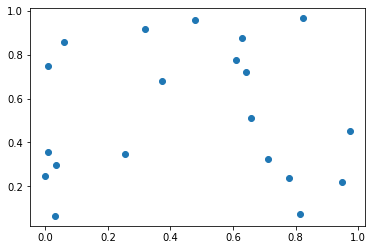

In [99]:
np.random.seed(13)
#np.random.seed(None)
pointsL = np.random.random_sample(size=(20,2))
plt.scatter(pointsL[:,0], pointsL[:,1])

In [100]:
L = getAlphaComplex(pointsL, .151)

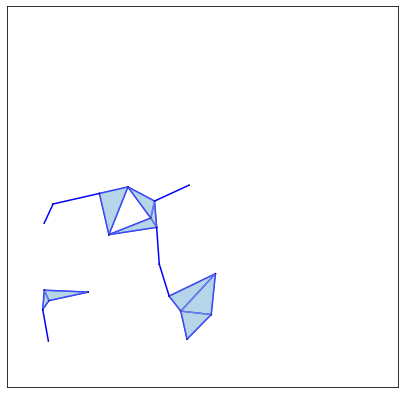

In [101]:
draw_2d_simplicial_complex(L, 5*pointsL)

In [102]:
newPoints = np.random.random_sample(size=(5,2))

pointsM = np.vstack((pointsL, newPoints))
pointsM = pointsL.copy()
pointsM.shape

(20, 2)

In [103]:
M = getAlphaComplex(pointsM, 4)

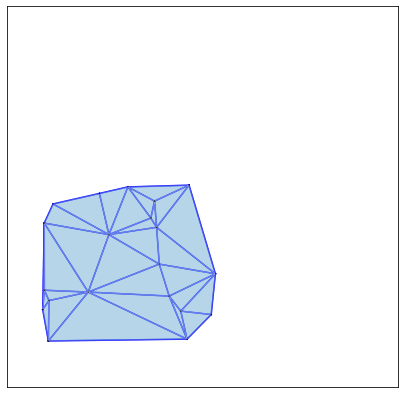

In [104]:
draw_2d_simplicial_complex(M, 5*pointsM)

In [105]:
sM, sPointsM = subdivision(M, pointsM, Subs)

In [106]:
sM, sPointsM, sL, sPointsL = subdivide_complex(M, pointsM, L, pointsL, Subs)

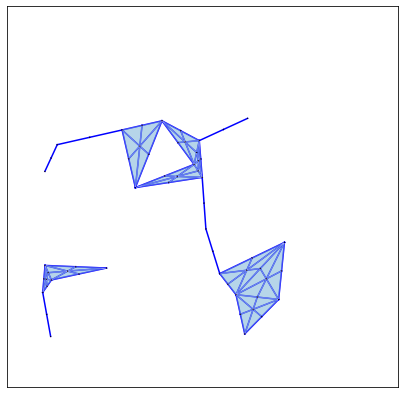

In [107]:
draw_2d_simplicial_complex(sL, 7*sPointsL)

### Compute outer boundary

In [108]:
outer_edges = compute_outer_boundary(sM)

In [109]:
outer_edges;

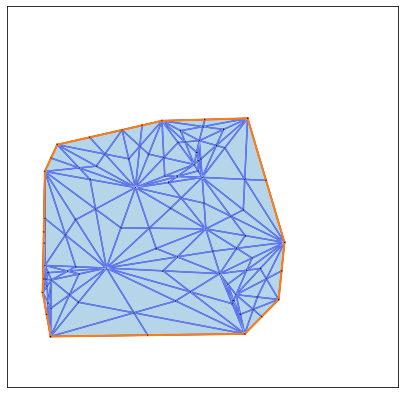

In [110]:
draw_2d_simplicial_complex(sM, 7*sPointsM, markedEdges=outer_edges)

### Compute supplement

In [111]:
Lbar, SubComplexIndices = compute_supplement(sM, sPointsM, sL, sPointsL)

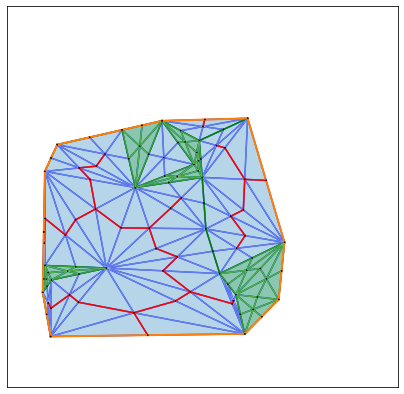

In [112]:
draw_Sup( sM , sL , Lbar, SubComplexIndices, pos = 7*sPointsM, posSub = 7*sPointsL, boundaryComponent = outer_edges )

### Connected components of $\bar{L}$

In [113]:
CC = connected_components(Lbar)

### Remove boundary connected components

In [114]:
validCC, excludedCC = discard_boundary_components(CC, outer_edges)

### Get list of excluded vertices

In [115]:
excludedVerts = [v for CC in excludedCC for v in CC]

### Plot

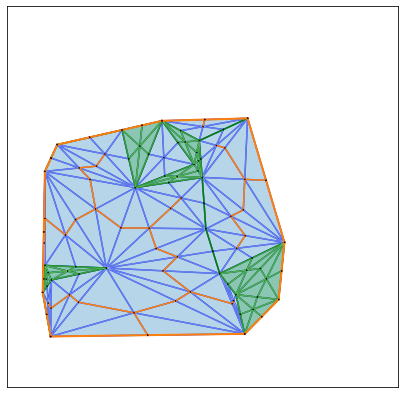

In [116]:
draw_Sup( sM , sL , Lbar, SubComplexIndices, pos = 7*sPointsM, posSub = 7*sPointsL, boundaryComponent = outer_edges, excludedVerts=excludedVerts)

### Representative cycles

In [117]:
repr_edges = extract_representatives(validCC,M, sM,pointsM)

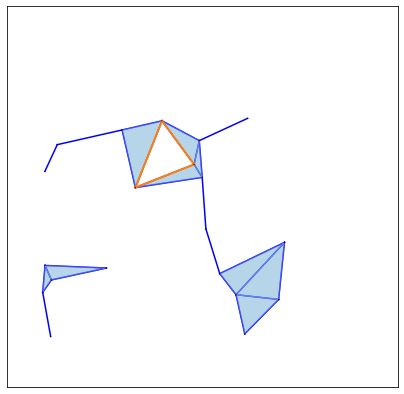

In [118]:
draw_2d_simplicial_complex(L,pos=7*pointsL, markedEdges=repr_edges)